In [ ]:
import warnings     #to supress the warnings
warnings.filterwarnings('ignore')

import numpy as np         #importing numpy and pandas
import pandas as pd

import matplotlib.pyplot as plt    #to visualise the code by graph
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
%matplotlib inline

# Read an explore the data

In [ ]:
# Try explicitly setting the delimiter and handling potential errors
data = pd.read_csv("creditcard.csv", sep=",", on_bad_lines='skip')
data.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
data.info()      #gives info of the deta

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122881 entries, 0 to 122880
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    122881 non-null  int64  
 1   V1      122881 non-null  float64
 2   V2      122881 non-null  float64
 3   V3      122881 non-null  float64
 4   V4      122881 non-null  float64
 5   V5      122881 non-null  float64
 6   V6      122881 non-null  float64
 7   V7      122881 non-null  float64
 8   V8      122881 non-null  float64
 9   V9      122881 non-null  float64
 10  V10     122880 non-null  float64
 11  V11     122880 non-null  float64
 12  V12     122880 non-null  float64
 13  V13     122880 non-null  float64
 14  V14     122880 non-null  float64
 15  V15     122880 non-null  float64
 16  V16     122880 non-null  float64
 17  V17     122880 non-null  float64
 18  V18     122880 non-null  float64
 19  V19     122880 non-null  float64
 20  V20     122880 non-null  float64
 21  V21     12

In [ ]:
# Check if any columns are of object type
object_columns = data.select_dtypes(include=['object'])
object_columns.head()


""
0
1
2
3
4


In [ ]:
# Convert all columns to numeric, forcing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')

# Check data types again
print(data.dtypes)

# Preview the data to see the changes
data.head(10)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
data.describe()   #gives the statistical summary of the data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,4.921720e+05,492172.000000,492171.000000,492171.000000,492170.000000,492168.000000,492168.000000,492167.000000,4.921640e+05,492163.000000,...,492124.000000,492120.000000,4.921140e+05,492112.000000,492107.000000,492100.000000,492094.000000,492087.000000,492080.000000,492077.000000
mean,5.953004e+11,0.040183,0.004978,-0.106508,-0.025780,0.043382,-0.014702,0.017981,2.743446e+04,0.000316,...,0.005347,0.016603,1.974041e+07,0.000453,-0.020842,-0.001678,0.001092,-0.000218,86.872632,0.001618
std,2.665100e+14,1.967378,1.648125,1.506910,1.421728,1.374689,1.360992,1.234048,1.477099e+07,1.090918,...,0.820463,0.737463,1.384806e+10,0.893725,0.539189,1.203880,0.836236,0.361447,246.619421,0.040187
min,0.000000e+00,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-7.321672e+01,-13.434066,...,-34.830382,-10.933144,-4.480774e+01,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,6.745100e+04,-0.904570,-0.598703,-1.046954,-0.865150,-0.653836,-0.786016,-0.544069,-2.188600e-01,-0.636512,...,-0.229166,-0.545512,-1.587696e-01,-0.359185,-0.339845,-0.326882,-0.071581,-0.055663,5.340000,0.000000
50%,1.144805e+05,0.034499,0.064672,0.039069,-0.056693,-0.009056,-0.294061,0.058602,1.391338e-02,-0.046422,...,-0.023261,0.025086,-3.951223e-03,0.037633,-0.019075,-0.048615,0.000015,0.007417,21.000000,0.000000
75%,1.433220e+05,1.481680,0.815341,0.934727,0.692101,0.660732,0.381249,0.593712,3.233446e-01,0.592174,...,0.196220,0.566737,1.590090e-01,0.450673,0.335742,0.233185,0.092756,0.078701,75.460000,0.000000
max,1.419290e+17,18.430000,22.057729,9.382558,25.900000,34.801666,179.790000,120.589494,9.599472e+09,18.430000,...,231.480000,10.503090,9.714530e+12,403.040000,58.000000,583.200000,494.990000,99.740000,25691.160000,1.000000


In [ ]:
missing_values = data.isnull().sum()   #checks for null values
missing_values

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#If there were missing values
for column in data.columns:
    if data[column].dtype == 'object':                              # Categorical column
        data[column].fillna(data[column].mode()[0], inplace=True)               #we use mode for categorical column
    else:                                                           # Numerical column
        data[column].fillna(data[column].mean(), inplace=True)                  #using mean for numerical column

In [ ]:
duplicate_rows = data.duplicated().sum()                    #this line checks for duplicate rows
print('Duplicate rows: ',duplicate_rows)

data = data.drop_duplicates()                               # this drops duplicate rows

Duplicate rows:  1081


In [ ]:
data.columns    #shows all columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

#Data Visualizations

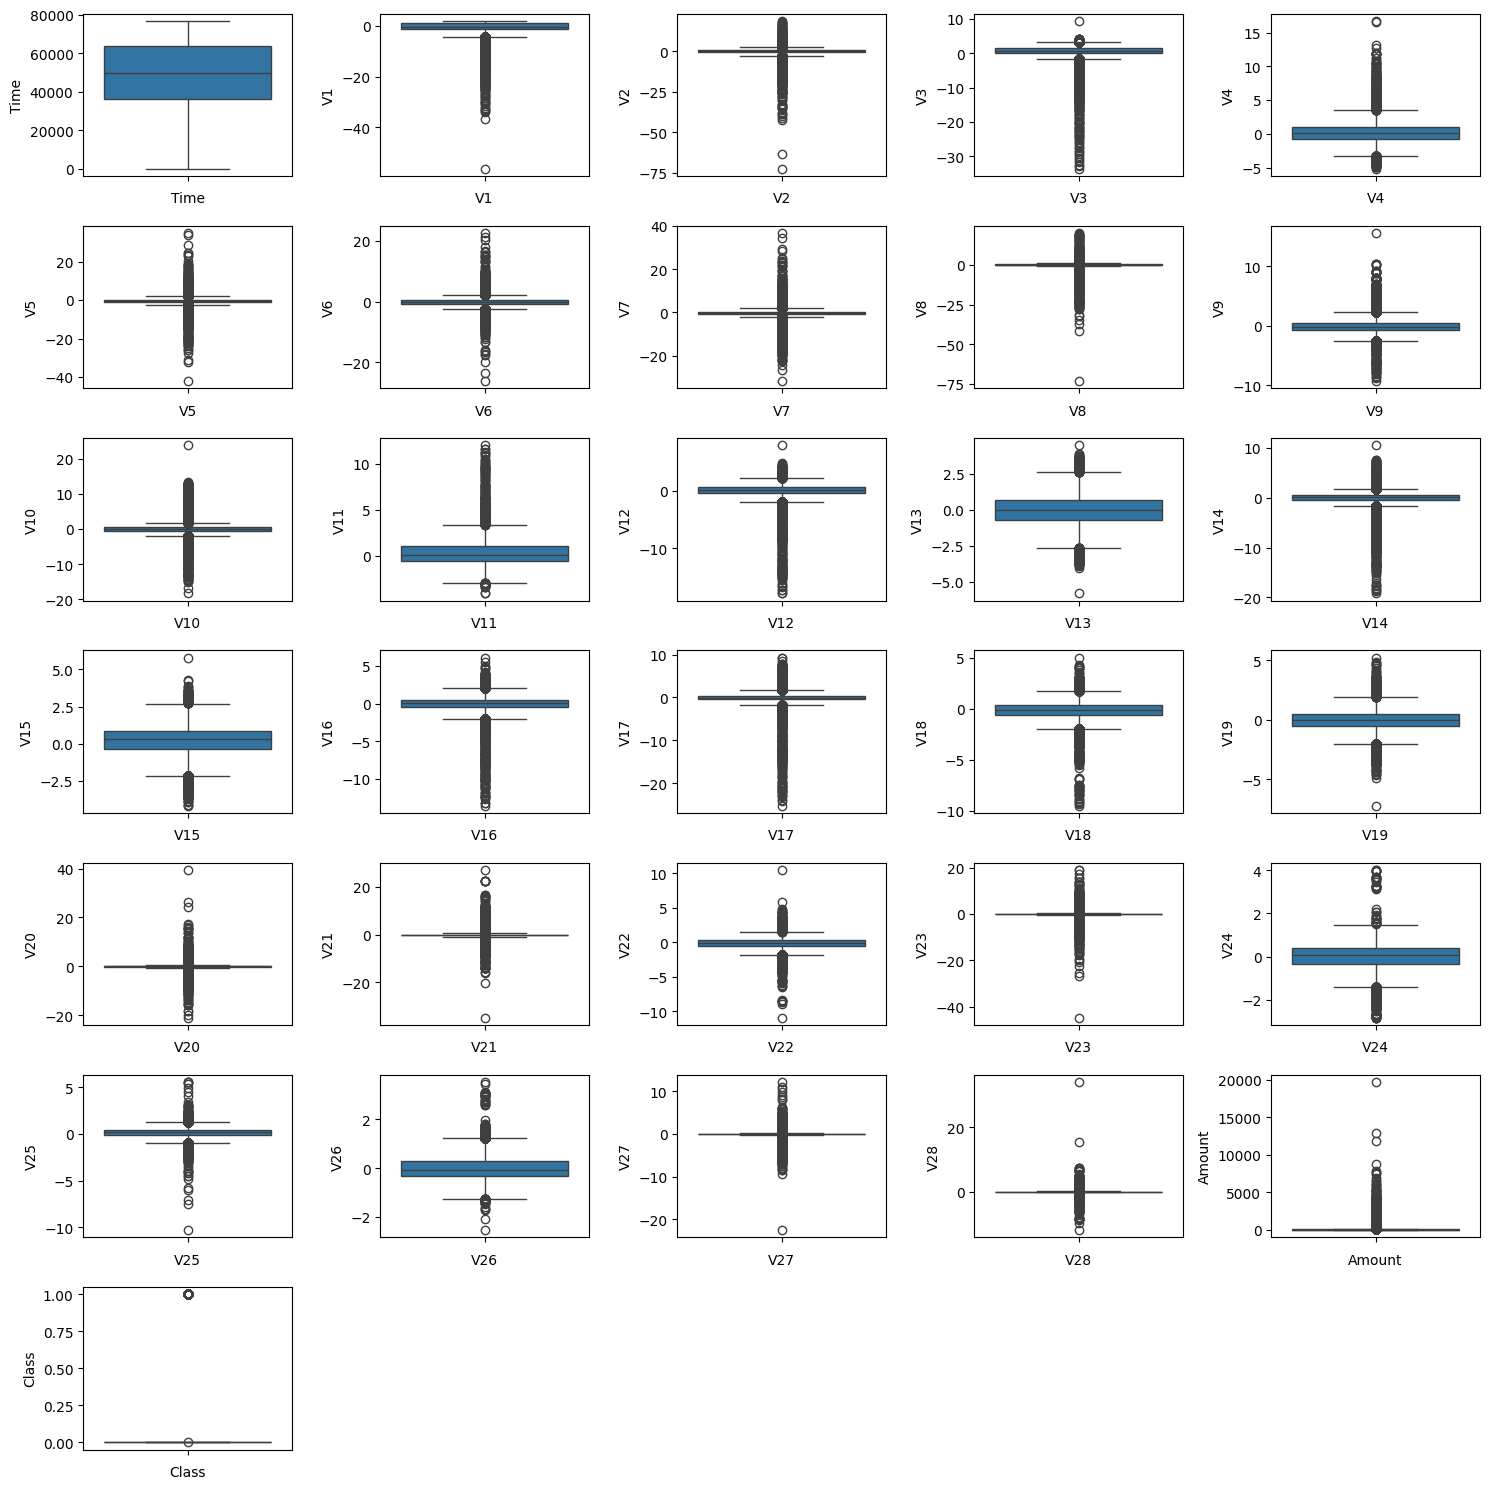

In [ ]:
fig, axs = plt.subplots(7, 5, figsize=(15, 15))       #creates 3x3 grid of subplots

# Creating boxplots for numerical columns
sns.boxplot(data['Time'], ax=axs[0, 0]).set(xlabel='Time')
sns.boxplot(data['V1'], ax=axs[0, 1]).set(xlabel='V1')
sns.boxplot(data['V2'], ax=axs[0, 2]).set(xlabel='V2')
sns.boxplot(data['V3'], ax=axs[0, 3]).set(xlabel='V3')
sns.boxplot(data['V4'], ax=axs[0, 4]).set(xlabel='V4')
sns.boxplot(data['V5'], ax=axs[1, 0]).set(xlabel='V5')
sns.boxplot(data['V6'], ax=axs[1, 1]).set(xlabel='V6')
sns.boxplot(data['V7'], ax=axs[1, 2]).set(xlabel='V7')
sns.boxplot(data['V8'], ax=axs[1, 3]).set(xlabel='V8')
sns.boxplot(data['V9'], ax=axs[1, 4]).set(xlabel='V9')
sns.boxplot(data['V10'], ax=axs[2, 0]).set(xlabel='V10')
sns.boxplot(data['V11'], ax=axs[2, 1]).set(xlabel='V11')
sns.boxplot(data['V12'], ax=axs[2, 2]).set(xlabel='V12')
sns.boxplot(data['V13'], ax=axs[2, 3]).set(xlabel='V13')
sns.boxplot(data['V14'], ax=axs[2, 4]).set(xlabel='V14')
sns.boxplot(data['V15'], ax=axs[3, 0]).set(xlabel='V15')
sns.boxplot(data['V16'], ax=axs[3, 1]).set(xlabel='V16')
sns.boxplot(data['V17'], ax=axs[3, 2]).set(xlabel='V17')
sns.boxplot(data['V18'], ax=axs[3, 3]).set(xlabel='V18')
sns.boxplot(data['V19'], ax=axs[3, 4]).set(xlabel='V19')
sns.boxplot(data['V20'], ax=axs[4, 0]).set(xlabel='V20')
sns.boxplot(data['V21'], ax=axs[4, 1]).set(xlabel='V21')
sns.boxplot(data['V22'], ax=axs[4, 2]).set(xlabel='V22')
sns.boxplot(data['V23'], ax=axs[4, 3]).set(xlabel='V23')
sns.boxplot(data['V24'], ax=axs[4, 4]).set(xlabel='V24')
sns.boxplot(data['V25'], ax=axs[5, 0]).set(xlabel='V25')
sns.boxplot(data['V26'], ax=axs[5, 1]).set(xlabel='V26')
sns.boxplot(data['V27'], ax=axs[5, 2]).set(xlabel='V27')
sns.boxplot(data['V28'], ax=axs[5, 3]).set(xlabel='V28')
sns.boxplot(data['Amount'], ax=axs[5, 4]).set(xlabel='Amount')
sns.boxplot(data['Class'], ax=axs[6, 0]).set(xlabel='Class')

# Hiding the last two empty subplots
axs[6, 1].axis('off')
axs[6, 2].axis('off')
axs[6, 3].axis('off')
axs[6, 4].axis('off')

# Adjusting the layout so that graphs dont overlay each other
plt.tight_layout()

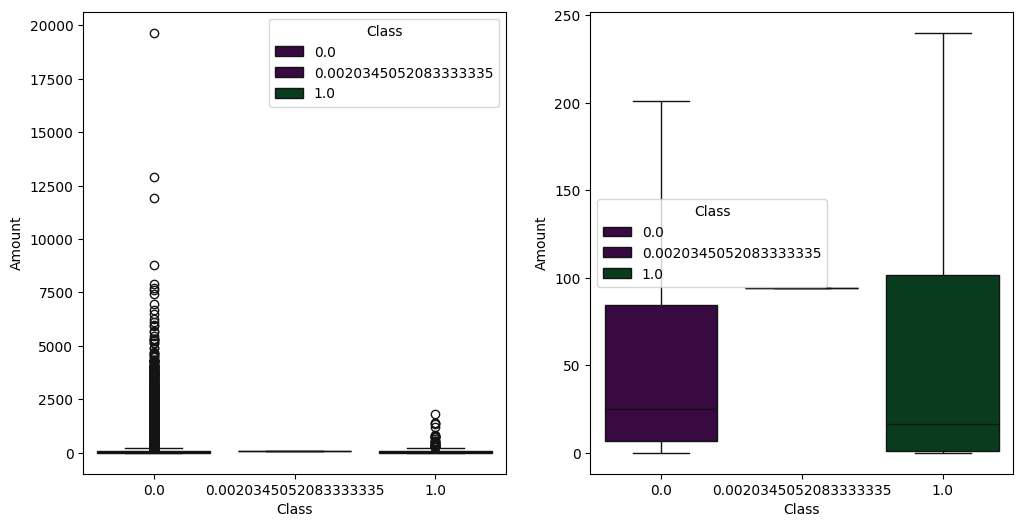

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
s = sns.boxplot(ax = ax1, x="Class", y="Amount", hue="Class",data=data, palette="PRGn",showfliers=True)
s = sns.boxplot(ax = ax2, x="Class", y="Amount", hue="Class",data=data, palette="PRGn",showfliers=False)
plt.show()

In [ ]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

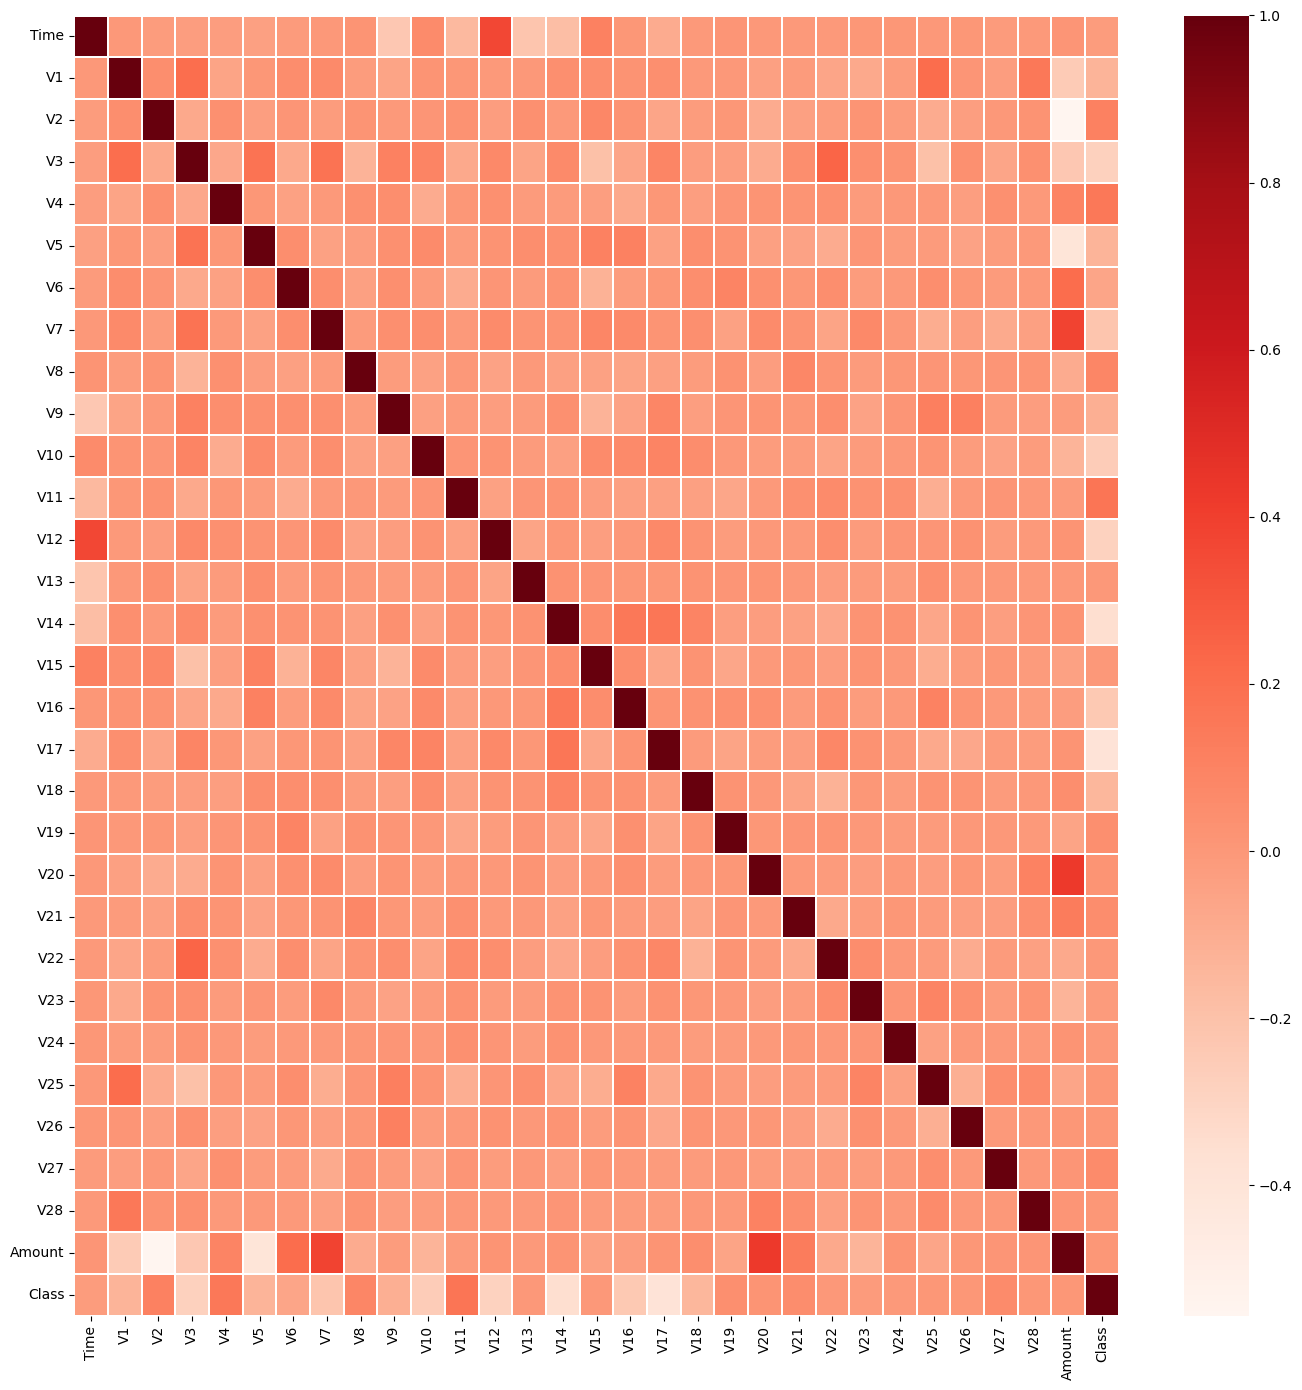

In [ ]:
#the final visualisation to show what affects what.

plt.figure(figsize=(14, 14))
dataplot = sns.heatmap(data[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class']].corr(),linewidths=.1, cmap="Reds")
plt.tight_layout()

In [ ]:
def train_test_split_and_scale(data):
    y = data['Class']
    x = data.drop('Class',axis=1)
    features = list(x.columns)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 42)
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test,features

In [ ]:
x_train, x_test, y_train, y_test,features = train_test_split_and_scale(data)

# Train test split and Data Scaling

In [ ]:
    # Feature scaling
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

In [ ]:
x_train, x_test, y_train, y_test,features = train_test_split_and_scale(data)

In [ ]:
Counter(y_train)

Counter({0: 226597, 1: 383})

In [ ]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test,class_weight=None):
    lr = LogisticRegression(class_weight=class_weight)
    model = lr.fit(x_train, y_train)
    lr_predict = lr.predict(x_test)
    lr_conf_matrix = confusion_matrix(y_test, lr_predict)
    lr_acc_score = accuracy_score(y_test, lr_predict)
    print("confussion matrix")
    print(lr_conf_matrix)
    print("\n")
    print("Accuracy of Logistic Regression:",lr_acc_score*100,'\n')
    print(classification_report(y_test,lr_predict))
    return model

In [ ]:
Counter(y_train)

Counter({0: 226597, 1: 383})

In [ ]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)
print("odds ratio", np.exp(model.coef_))

confussion matrix
[[56651     5]
 [   47    43]]


Accuracy of Logistic Regression: 99.90836358509851 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.90      0.48      0.62        90

    accuracy                           1.00     56746
   macro avg       0.95      0.74      0.81     56746
weighted avg       1.00      1.00      1.00     56746

odds ratio [[1.78815457e+00 1.29126537e+00 1.48710934e+00 3.81992178e-01
  2.12900691e+03 2.93293573e+00 3.88698671e-01 4.63656147e-01
  1.80862785e-01 9.13061176e-02 1.64338437e-02 2.39477158e+02
  2.17667507e-03 1.54308643e-01 1.62849072e-05 6.13693233e-01
  3.69695697e-02 2.07900629e-01 1.01083930e+00 1.27559768e+00
  1.42164493e+00 2.72122250e+00 2.56092096e+00 7.10675289e-01
  4.37190153e-01 4.70045925e-01 1.52047968e+00 6.96879690e-01
  1.22077480e+00 7.08862107e-01]]


# Improve the model

In [ ]:
# define class weights
weight = {0:1, 1:3}
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,class_weight=weight)


confussion matrix
[[56649     7]
 [   37    53]]


Accuracy of Logistic Regression: 99.92246149508335 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.88      0.59      0.71        90

    accuracy                           1.00     56746
   macro avg       0.94      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
results = pd.DataFrame(model.predict_proba(x_test))
results.columns = ['class_0_proba','class_1_proba']
results['predicted_class'] = model.predict(x_test)
results

,class_0_proba,class_1_proba,predicted_class
0,0.999046,0.000954,0
1,0.999620,0.000380,0
2,0.999701,0.000299,0
3,0.999189,0.000811,0
4,0.998334,0.001666,0
...,...,...,...
56741,0.993485,0.006515,0
56742,0.998959,0.001041,0
56743,0.999185,0.000815,0
56744,0.998650,0.001350,0


In [ ]:
#save and reuse the model

In [ ]:
import joblib  # 'pip install joblib' if you get "Package Not found Error"
joblib.dump(model , 'CreditCard_Fraud_Detection.pkl')

['CreditCard_Fraud_Detection.pkl']

In [ ]:
import joblib
model_read = joblib.load('CreditCard_Fraud_Detection.pkl')
model_read.predict(x_test)

array([0, 0, 0, ..., 0, 0, 0])

# Model interpretation

In [ ]:
# Feature importance
# Odds ratio well higher than 1: Increase in fetaure value increases probability of event hapenning

# A feature with an odds ratio near zero typically suggests that the associated predictor has
#a strong negative impact on the odds of the event occurring.

# Odds ratio near 1 indicates that feature may not be a strong predictor

In [ ]:
odds_ratio = np.exp(model.coef_)[0]

for z in range(len(features)):
     print("Odds ratio for feature {} is {}".format(features[z], odds_ratio[z]))

Odds ratio for feature Time is 1.2244512600555988
Odds ratio for feature V1 is 2.150899601744729
Odds ratio for feature V2 is 0.968382713215054
Odds ratio for feature V3 is 0.5234096078370837
Odds ratio for feature V4 is 9799.464908253292
Odds ratio for feature V5 is 5.8709528359794385
Odds ratio for feature V6 is 0.2418486208506697
Odds ratio for feature V7 is 0.31876689251214596
Odds ratio for feature V8 is 0.02589730341090031
Odds ratio for feature V9 is 0.10399017322555747
Odds ratio for feature V10 is 0.0014399926094410263
Odds ratio for feature V11 is 421.78622124993984
Odds ratio for feature V12 is 0.0002842399935650491
Odds ratio for feature V13 is 0.08279991205236151
Odds ratio for feature V14 is 5.926435484450618e-07
Odds ratio for feature V15 is 0.3870847509152881
Odds ratio for feature V16 is 0.008565336056896558
Odds ratio for feature V17 is 0.15984351947517134
Odds ratio for feature V18 is 1.0580613681328217
Odds ratio for feature V19 is 1.2387620069830096
Odds ratio for 